### Author: Abhipsa Acharya

# Trigger Efficiency Study -- Run 3 (2024)
## Boosted + Resolved All-Hadronic $t\bar{t}$

Using centrally produced TTto4Q NanoAOD accessed via XRootD from cmslpc.  
Triggers matched to the **JetMET** primary dataset (Run 3, 2024 HLT menu).  
109.4 fb$^{-1}$ total integrated luminosity.

Key 2024 menu changes vs 2023:
- DiJet triggers: `MassSD` renamed to `SoftDropMass`, new `260_260_SoftDropMass40` variant
- Single-jet mass triggers: `MassSD` -> `SoftDropMass`, new lower thresholds (380, 400 GeV)
- AK8 Jet+SoftDrop: thresholds now at `SoftDropMass30` (was `SoftDropMass40` in 2022-2023)
- DeepJet-based resolved triggers: **completely removed**
- New PNet-based dijet triggers replace DeepJet resolved paths
- New AK8 Nch (charged multiplicity) triggers
- AK8+PNet single-jet triggers unchanged from 2023

In [1]:
import subprocess
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import mplhep as hep
plt.style.use(hep.style.CMS)

%matplotlib inline
print('Ready')

/cvmfs/cms.cern.ch/el9_amd64_gcc11/external/py3-numpy/1.22.4-1e1240160543ee39175a125e9a5e9cae/lib/python3.9/site-packages/numpy/core/getlimits.py:499: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/cvmfs/cms.cern.ch/el9_amd64_gcc11/external/py3-numpy/1.22.4-1e1240160543ee39175a125e9a5e9cae/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/cvmfs/cms.cern.ch/el9_amd64_gcc11/external/py3-numpy/1.22.4-1e1240160543ee39175a125e9a5e9cae/lib/python3.9/site-packages/numpy/core/getlimits.py:499: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/cvmfs/cms.cern.ch/el9_amd64_gcc11/external/py3-numpy/1.22.4-1e1240160543ee39175a125e9a5e9cae/lib/python3.9/site-pac

Ready


In [12]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

_pdf_pages = PdfPages(f"TEff_Run3_plots.pdf")
_orig_show = plt.show

def _show_and_save(*args, **kwargs):
    for fn in plt.get_fignums():
        _pdf_pages.savefig(plt.figure(fn), bbox_inches='tight')
    _orig_show(*args, **kwargs)

plt.show = _show_and_save
print("PDF capture enabled: every plt.show() will also save to PDF")

PDF capture enabled: every plt.show() will also save to PDF


## 1. Era configuration
**2024 datasets may not yet be available in NanoAODv12/v14.**  
If DAS returns 0 files, check the CMS MC production status.

The notebook includes a DAS auto-discovery fallback that searches for  
`TTto4Q*Run3Summer24*NANOAODSIM` if the exact path is not found.

In [13]:
# CHANGE THIS TO SWITCH ERAS

ERA = "Run3_2024"  # Options: "Run3_2024", "Run3_2024BPix"
N_FILES = 3

DATASETS = {
    # Run 3 2024 -- NanoAODv14 (best guess, may need updating)
    # If these exact paths fail, the DAS wildcard fallback will try to resolve
    "Run3_2024":     "/TTto4Q-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8/Run3Summer24NanoAODv14-140X_mcRun3_2024_realistic_v26-v1/NANOAODSIM",
    "Run3_2024BPix": "/TTto4Q-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8/Run3Summer24BPixNanoAODv14-140X_mcRun3_2024_realistic_postBPix_v4-v1/NANOAODSIM",
}

LUMIS = {
    "Run3_2024":     "TBD fb$^{-1}$",
    "Run3_2024BPix": "TBD fb$^{-1}$",
}

ENERGY = "13.6 TeV"
DATASET = DATASETS[ERA]
LUMI_TEXT = LUMIS[ERA] + f" ({ENERGY})"
IS_2023 = False
IS_2024 = True
print(f"Era: {ERA}")
print(f"Dataset: {DATASET}")
print(f"Note: If DAS fails, check CMS MC production status or update dataset path.")

Era: Run3_2024
Dataset: /TTto4Q-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8/Run3Summer24NanoAODv14-140X_mcRun3_2024_realistic_v26-v1/NANOAODSIM
Note: If DAS fails, check CMS MC production status or update dataset path.


## 2. Query DAS and open files via XRootD
Using multiple files for better statistics in the turn-on tails.

In [14]:
# Query DAS -- enhanced fallback for 2024 datasets
print(f"Querying DAS for {N_FILES} files...")
r = subprocess.run(
    ["dasgoclient", "-query", f"file dataset={DATASET}", "-limit", str(N_FILES)],
    capture_output=True, text=True, timeout=120
)
fnames = [f.strip() for f in r.stdout.strip().split('\n') if f.strip()]

# If exact path fails, try progressively broader wildcards
if not fnames:
    print("Exact path returned 0 files, trying wildcards...")
    
    # Try 1: Wildcard on version
    parts = DATASET.split("/")
    wildcard_queries = [
        f"dataset=/{parts[1]}/*Run3Summer24*/{parts[3]}",
        f"dataset=/TTto4Q*/*Run3Summer24*NanoAOD*/NANOAODSIM",
        f"dataset=/TTto4Q*/*Run3*2024*/NANOAODSIM",
    ]
    
    for wq in wildcard_queries:
        print(f"  Trying: {wq}")
        r2 = subprocess.run(
            ["dasgoclient", "-query", wq],
            capture_output=True, text=True, timeout=120
        )
        resolved = [d.strip() for d in r2.stdout.strip().split('\n') if d.strip()]
        if resolved:
            print(f"  Found {len(resolved)} matching datasets:")
            for ds in resolved[:5]:
                print(f"    {ds}")
            # Use the first match
            DATASET = resolved[0]
            r3 = subprocess.run(
                ["dasgoclient", "-query", f"file dataset={DATASET}", "-limit", str(N_FILES)],
                capture_output=True, text=True, timeout=120
            )
            fnames = [f.strip() for f in r3.stdout.strip().split('\n') if f.strip()]
            if fnames:
                break
    
    if not fnames:
        print("\nNo 2024 TTto4Q NanoAOD datasets found yet.")
        print("Options:")
        print("  1. Check CMS MC production: https://cms-pdmv.cern.ch/mcm/")
        print("  2. Check DAS directly: https://cmsweb.cern.ch/das/")
        print("  3. Ask your analysis group for the correct dataset path")
        raise RuntimeError("No files found. Update DATASET path and rerun.")

print(f"\nUsing dataset: {DATASET}")
print(f"Got {len(fnames)} files:")
for fn in fnames:
    print(f"  {fn}")

urls = ["root://cmsxrootd.fnal.gov/" + fn for fn in fnames]

Querying DAS for 3 files...
Exact path returned 0 files, trying wildcards...
  Trying: dataset=/TTto4Q-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8/*Run3Summer24*/NANOAODSIM
  Trying: dataset=/TTto4Q*/*Run3Summer24*NanoAOD*/NANOAODSIM
  Trying: dataset=/TTto4Q*/*Run3*2024*/NANOAODSIM
  Found 6 matching datasets:
    /TTto4Q-3Jets_TuneCP5_13p6TeV_madgraphMLM-pythia8/RunIII2024Summer24NanoAODv15-150X_mcRun3_2024_realistic_v2-v2/NANOAODSIM
    /TTto4Q-BBDPS_TuneCP5_13p6TeV_powheg-pythia8/RunIII2024Summer24NanoAODv15-150X_mcRun3_2024_realistic_v2-v2/NANOAODSIM
    /TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/RunIII2024Summer24NanoAOD-140X_mcRun3_2024_realistic_v26-v2/NANOAODSIM
    /TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/RunIII2024Summer24NanoAODv15-150X_mcRun3_2024_realistic_v2-v2/NANOAODSIM
    /TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/RunIII2024Summer24NanoAODv15-BTVNanoV15_150X_mcRun3_2024_realistic_v2-v1/NANOAODSIM

Using dataset: /TTto4Q-3Jets_TuneCP5_13p6TeV_madgraphMLM-pythia8/RunIII2024Summer

## 3. Discover available triggers
Open the first file to get the branch list, then auto-detect trigger families.

In [15]:
first = uproot.open(urls[0])["Events"]
all_branches = first.keys()

hlt_all = sorted([b for b in all_branches if b.startswith("HLT_")])
print(f"Branches: {len(all_branches)}, HLT triggers: {len(hlt_all)}")

# Quick sanity: check for key Run 3 trigger families
for pattern in ["AK8DiPFJet", "SoftDropMass", "MassSD", "PNet", "ParticleNet", "DeepJet"]:
    matches = [t for t in hlt_all if pattern in t]
    print(f"  {pattern}: {len(matches)} triggers found")

Branches: 2007, HLT triggers: 716
  AK8DiPFJet: 7 triggers found
  SoftDropMass: 39 triggers found
  MassSD: 0 triggers found
  PNet: 97 triggers found
  ParticleNet: 0 triggers found
  DeepJet: 2 triggers found


## 4. Define trigger groups -- 2024 HLT menu

Only triggers actually present in the NanoAOD file are kept via `keep()`.

### Key 2024 naming changes
- **DiJet:** `MassSD` -> `SoftDropMass` (same physics, different string)
- **Single-jet mass:** `MassSD` -> `SoftDropMass`, lower pT thresholds (380, 400)
- **AK8 Jet+SD:** Mass cut lowered from 40 to 30 GeV at 425/450
- **Resolved:** DeepJet triggers gone, replaced by PNet dijet triggers
- **New:** AK8 charged multiplicity (Nch) triggers

In [16]:
def keep(trig_list):
    """Filter to triggers actually present in the NanoAOD file."""
    return [t for t in trig_list if t in hlt_all]

# GROUP 1: AK8 PFHT + TrimMass (boosted)
# REMOVED since 2023

boosted_ak8ht_trim = keep([
    "HLT_AK8PFHT800_TrimMass50",
    "HLT_AK8PFHT850_TrimMass50",
    "HLT_AK8PFHT900_TrimMass50",
])

# GROUP 2: AK8 single jet + SoftDropMass (boosted)
# 2024: Mass cut lowered to 30 GeV, new lower pT thresholds
# NOTE: SoftDropMass40 still exists at 220/230 for lepton+jet triggers

boosted_ak8jet_sd = keep([
    # 2024 SoftDropMass30 variants (new lower mass cut)
    "HLT_AK8PFJet380_SoftDropMass30",   # 109.4 fb-1 (NEW in 2024)
    "HLT_AK8PFJet400_SoftDropMass30",   # 109.4 fb-1 (NEW in 2024)
    "HLT_AK8PFJet425_SoftDropMass30",   # 109.4 fb-1 (threshold lowered from mSD40)
    "HLT_AK8PFJet450_SoftDropMass30",   # 109.4 fb-1 (threshold lowered from mSD40)
    # Check if old SoftDropMass40 naming still exists
    "HLT_AK8PFJet425_SoftDropMass40",
    "HLT_AK8PFJet450_SoftDropMass40",
])

# GROUP 3: AK8 DiPFJet + SoftDropMass (boosted dijet)
# 2024: MassSD -> SoftDropMass, new 260_260_SoftDropMass40 variant
boosted_ak8dijet = keep([
    "HLT_AK8DiPFJet250_250_SoftDropMass40",  # 109.4 fb-1 (NEW naming)
    "HLT_AK8DiPFJet250_250_SoftDropMass50",  # 109.4 fb-1 (was MassSD50)
    "HLT_AK8DiPFJet260_260_SoftDropMass30",  # 109.4 fb-1 (NEW naming)
    "HLT_AK8DiPFJet260_260_SoftDropMass40",  # 109.4 fb-1 (NEW in 2024)
    "HLT_AK8DiPFJet270_270_SoftDropMass30",  # 109.4 fb-1 (was MassSD30)
    "HLT_AK8DiPFJet280_280_SoftDropMass30",  # 109.4 fb-1 (was MassSD30)
    "HLT_AK8DiPFJet290_290_SoftDropMass30",  # 109.4 fb-1 (was MassSD30)
    # Also check old MassSD naming in case MC has it
    "HLT_AK8DiPFJet250_250_MassSD50",
    "HLT_AK8DiPFJet270_270_MassSD30",
    "HLT_AK8DiPFJet280_280_MassSD30",
    "HLT_AK8DiPFJet290_290_MassSD30",
])

# GROUP 4: AK8 + SoftDropMass (single jet, no b-tag)
# 2024: MassSD -> SoftDropMass, same thresholds as Group 2
# This group is now merged into Group 2 since naming unified
# Keep empty for structural compatibility
boosted_ak8jet_msd = keep([
    # 2024 does not have separate MassSD triggers anymore
    # They are now the SoftDropMass triggers in Group 2
    "HLT_AK8PFJet420_MassSD30",
    "HLT_AK8PFJet450_MassSD30",
    "HLT_AK8PFJet470_MassSD30",
    "HLT_AK8PFJet500_MassSD30",
])

# GROUP 5: AK8 pure high-pT (boosted)
# Unchanged from 2023
boosted_ak8jet_pt = keep([
    "HLT_AK8PFJet500",                 # 109.4 fb-1
    "HLT_AK8PFJet550",                 # 109.4 fb-1
])

# GROUP 6: AK8 + PNet b-tag (boosted)
# Unchanged from 2023
boosted_ak8_pnet = keep([
    "HLT_AK8PFJet230_SoftDropMass40_PNetBB0p06",  # 109.4 fb-1
    "HLT_AK8PFJet230_SoftDropMass40_PNetBB0p10",  # 109.4 fb-1
    "HLT_AK8PFJet250_SoftDropMass40_PNetBB0p06",  # 109.4 fb-1
    "HLT_AK8PFJet250_SoftDropMass40_PNetBB0p10",  # 109.4 fb-1
    "HLT_AK8PFJet275_SoftDropMass40_PNetBB0p06",  # 109.4 fb-1
    "HLT_AK8PFJet275_SoftDropMass40_PNetBB0p10",  # 109.4 fb-1
])

# GROUP 7: Resolved multi-jet
# 2024: DeepJet triggers COMPLETELY REMOVED
# Replaced by PNet-based dijet triggers
resolved_multijet = keep([
    # DeepJet triggers (check if still present, likely absent)
    "HLT_PFHT330PT30_QuadPFJet_75_60_45_40_TriplePFBTagDeepJet_4p5",
    "HLT_PFHT400_FivePFJet_100_100_60_30_30_DoublePFBTagDeepJet_4p5",
    "HLT_PFHT400_FivePFJet_120_120_60_30_30_DoublePFBTagDeepJet_4p5",
    "HLT_PFHT400_SixPFJet32_DoublePFBTagDeepJet_2p94",
    "HLT_PFHT450_SixPFJet36_PFBTagDeepJet_1p59",
    # PNet-based (check if present in NanoAOD)
    "HLT_PFHT340_QuadPFJet70_50_40_40_PNet2BTagMean0p70",
    # 2024 PNet dijet triggers (NEW)
    "HLT_DoublePFJets116MaxDeta1p6_PNet2BTag_0p11",   # 109.4 fb-1
    "HLT_DoublePFJets128MaxDeta1p6_PNet2BTag_0p11",   # 109.4 fb-1
    "HLT_Mu12_DoublePFJets40MaxDeta1p6_PNet2BTag_0p11",  # 109.4 fb-1
    "HLT_Mu12_DoublePFJets54MaxDeta1p6_PNet2BTag_0p11",  # 109.4 fb-1
])

# GROUP 8: Inclusive PFHT
# Unchanged
inclusive_pfht = keep([
    "HLT_PFHT1050",                    # 109.4 fb-1
])

# GROUP 9: Hybrid AK8+AK4 PNet (boosted+resolved)
# Unchanged from 2023
hybrid_ak8_pnet = keep([
    "HLT_AK8PFJet220_SoftDropMass40_PNetBB0p06_DoubleAK4PFJet60_30_PNet2BTagMean0p50",
    "HLT_AK8PFJet220_SoftDropMass40_PNetBB0p06_DoubleAK4PFJet60_30_PNet2BTagMean0p53",
    "HLT_AK8PFJet220_SoftDropMass40_PNetBB0p06_DoubleAK4PFJet60_30_PNet2BTagMean0p55",
    "HLT_AK8PFJet220_SoftDropMass40_PNetBB0p06_DoubleAK4PFJet60_30_PNet2BTagMean0p60",
])

# GROUP 10 (NEW): AK8 charged multiplicity (Nch)
# New in 2024: targets quark vs gluon jet discrimination
boosted_ak8_nch = keep([
    "HLT_AK8PFJet275_Nch40",           # 109.4 fb-1
    "HLT_AK8PFJet275_Nch45",           # 109.4 fb-1
])

# -- Assemble all groups --
all_groups = [
    ("Boosted AK8 HT+TrimMass (ABSENT)",         boosted_ak8ht_trim),
    ("Boosted AK8 Jet+SoftDrop",                  boosted_ak8jet_sd),
    ("Boosted AK8 DiJet+SoftDropMass",            boosted_ak8dijet),
    ("Boosted AK8 Jet+MassSD (legacy, likely empty)", boosted_ak8jet_msd),
    ("Boosted AK8 Jet pure pT",                   boosted_ak8jet_pt),
    ("Boosted AK8 + PNet b-tag",                  boosted_ak8_pnet),
    ("Resolved Multi-jet (PNet replaces DeepJet)", resolved_multijet),
    ("Inclusive PFHT",                              inclusive_pfht),
    ("Hybrid AK8+AK4 PNet",                        hybrid_ak8_pnet),
    ("AK8 Charged Multiplicity (NEW 2024)",         boosted_ak8_nch),
]

all_triggers = []
for name, trigs in all_groups:
    print(f"{name} ({len(trigs)}):")
    for t in trigs:
        print(f"  {t}")
    all_triggers.extend(trigs)
print(f"\nTotal: {len(all_triggers)} triggers")

Boosted AK8 HT+TrimMass (ABSENT) (0):
Boosted AK8 Jet+SoftDrop (4):
  HLT_AK8PFJet380_SoftDropMass30
  HLT_AK8PFJet400_SoftDropMass30
  HLT_AK8PFJet425_SoftDropMass30
  HLT_AK8PFJet450_SoftDropMass30
Boosted AK8 DiJet+SoftDropMass (7):
  HLT_AK8DiPFJet250_250_SoftDropMass40
  HLT_AK8DiPFJet250_250_SoftDropMass50
  HLT_AK8DiPFJet260_260_SoftDropMass30
  HLT_AK8DiPFJet260_260_SoftDropMass40
  HLT_AK8DiPFJet270_270_SoftDropMass30
  HLT_AK8DiPFJet280_280_SoftDropMass30
  HLT_AK8DiPFJet290_290_SoftDropMass30
Boosted AK8 Jet+MassSD (legacy, likely empty) (0):
Boosted AK8 Jet pure pT (2):
  HLT_AK8PFJet500
  HLT_AK8PFJet550
Boosted AK8 + PNet b-tag (6):
  HLT_AK8PFJet230_SoftDropMass40_PNetBB0p06
  HLT_AK8PFJet230_SoftDropMass40_PNetBB0p10
  HLT_AK8PFJet250_SoftDropMass40_PNetBB0p06
  HLT_AK8PFJet250_SoftDropMass40_PNetBB0p10
  HLT_AK8PFJet275_SoftDropMass40_PNetBB0p06
  HLT_AK8PFJet275_SoftDropMass40_PNetBB0p10
Resolved Multi-jet (PNet replaces DeepJet) (6):
  HLT_PFHT330PT30_QuadPFJet_75_60

## 5. Bulk load from all files

All branches read in one call per file, then concatenated.
Strategy: query DAS for 10 file candidates but only need 3. If a file times out, skip and try the next.

In [17]:
import time

# Get more files than needed so we can skip bad ones
print("Querying DAS for 10 files...")
r = subprocess.run(
    ["dasgoclient", "-query", f"file dataset={DATASET}", "-limit", "10"],
    capture_output=True, text=True, timeout=60
)
fnames = [f.strip() for f in r.stdout.strip().split('\n') if f.strip()]
print(f"Got {len(fnames)} candidates")

branches_to_load = [
    "FatJet_pt", "FatJet_eta", "FatJet_mass", "FatJet_msoftdrop",
    "Jet_pt", "Jet_eta",
    "GenPart_pt", "GenPart_eta", "GenPart_pdgId", "GenPart_status",
] + all_triggers

chunks = []
for i, fn in enumerate(fnames):
    if len(chunks) >= N_FILES:
        break
    url = "root://cmsxrootd.fnal.gov/" + fn
    print(f"Trying file {i+1}: {fn.split('/')[-1]}...", end=" ")
    try:
        ev = uproot.open(url, timeout=120)["Events"]
        chunk = ev.arrays(branches_to_load, library="ak")
        print(f"OK, {len(chunk)} events")
        chunks.append(chunk)
    except Exception as e:
        print(f"SKIP ({e.__class__.__name__})")
        continue

data = ak.concatenate(chunks)
N = len(data)
print(f"\nLoaded {len(chunks)} files, {N} total events")

Querying DAS for 10 files...
Got 10 candidates
Trying file 1: 73bb5f42-6260-43b0-8b40-d813e3a3de08.root... OK, 44816 events
Trying file 2: 9293e89e-6898-4f00-9051-0f9cb516ded0.root... OK, 146082 events
Trying file 3: f3a9631c-2f43-4bae-8c7f-b1f3858f4a9a.root... OK, 123527 events

Loaded 3 files, 314425 total events


## 6. Build kinematic variables — sanity checks

In [18]:
fj_pt = data["FatJet_pt"]
fj_msoftdrop = data["FatJet_msoftdrop"]
jet_pt = data["Jet_pt"]

has_fj = ak.num(fj_pt) >= 1
has_fj_np = ak.to_numpy(has_fj)
lead_fj_pt = ak.to_numpy(ak.flatten(fj_pt[has_fj][:, 0:1]))
lead_fj_msd = ak.to_numpy(ak.flatten(fj_msoftdrop[has_fj][:, 0:1]))

has_2fj = ak.num(fj_pt) >= 2
has_2fj_np = ak.to_numpy(has_2fj)
sublead_fj_pt = ak.to_numpy(ak.flatten(fj_pt[has_2fj][:, 1:2]))

ak8_ht = ak.to_numpy(ak.sum(fj_pt[fj_pt > 200], axis=1))
ht = ak.to_numpy(ak.sum(jet_pt[jet_pt > 30], axis=1))
njet = ak.to_numpy(ak.num(jet_pt[jet_pt > 30]))

# DiJet variables for Group 3
# Min pT of the two leading fat jets (relevant for DiPFJet threshold)
has_2fj_lead = ak.to_numpy(ak.flatten(fj_pt[has_2fj][:, 0:1]))
has_2fj_sub  = ak.to_numpy(ak.flatten(fj_pt[has_2fj][:, 1:2]))
dijet_min_pt = np.minimum(has_2fj_lead, has_2fj_sub)

print(f"Events with >= 1 FatJet: {np.sum(has_fj_np)}/{N}")
print(f"Events with >= 2 FatJets: {np.sum(has_2fj_np)}/{N}")
print(f"Lead FatJet pT: {np.min(lead_fj_pt):.0f} - {np.max(lead_fj_pt):.0f} GeV")
print(f"AK4 HT: {np.min(ht):.0f} - {np.max(ht):.0f} GeV")
print(f"Njet(pT>30): {np.min(njet)} - {np.max(njet)}")

Events with >= 1 FatJet: 84745/314425
Events with >= 2 FatJets: 38829/314425
Lead FatJet pT: 170 - 1804 GeV
AK4 HT: 0 - 4082 GeV
Njet(pT>30): 0 - 17


## 7. Gen-level sanity check

In [19]:
gen_pdgId = data["GenPart_pdgId"]
gen_status = data["GenPart_status"]
gen_pt = data["GenPart_pt"]
is_top = (abs(gen_pdgId) == 6) & (gen_status == 62)
top_pt = gen_pt[is_top]

print(f"Events with 2 tops: {ak.sum(ak.num(top_pt) == 2)}/{N}")
flat_top = ak.flatten(top_pt)
print(f"Top pT: {ak.min(flat_top):.0f} - {ak.max(flat_top):.0f} GeV, mean={ak.mean(flat_top):.0f} GeV")

Events with 2 tops: 314425/314425
Top pT: 0 - 1804 GeV, mean=127 GeV


## 8. Efficiency calculator and plotting tools
Clopper-Pearson 68% confidence intervals computed bin-by-bin.
"""
    Calculate trigger efficiency with Clopper-Pearson errors.
    
    Parameters
    passed : boolean array — events that passed the trigger (already masked to baseline)
    variable : array — kinematic variable to bin (already masked to baseline)
    bins : array — bin edges
    
    Returns
    centers, widths, eff, elo, ehi

In [20]:
def calc_eff(passed, variable, bins):
    
    total_h, _ = np.histogram(variable, bins=bins)
    passed_h, _ = np.histogram(variable[passed], bins=bins)
    centers = (bins[:-1] + bins[1:]) / 2
    widths = (bins[1:] - bins[:-1]) / 2
    eff = np.zeros(len(total_h), dtype=float)
    elo = np.zeros(len(total_h), dtype=float)
    ehi = np.zeros(len(total_h), dtype=float)
    alpha = 0.3173  # 68% CL
    for i in range(len(total_h)):
        n, k = total_h[i], passed_h[i]
        if n > 0:
            eff[i] = k / n
            if k > 0:
                elo[i] = eff[i] - stats.beta.ppf(alpha / 2, k, n - k + 1)
            if k < n:
                ehi[i] = stats.beta.ppf(1 - alpha / 2, k + 1, n - k) - eff[i]
    return centers, widths, eff, elo, ehi

pt_bins = np.linspace(150, 1200, 30)
ht_bins = np.linspace(200, 2500, 30)
ak8ht_bins = np.linspace(0, 2500, 30)
njet_bins = np.arange(-0.5, 16.5, 1)
msd_bins = np.linspace(0, 300, 25)
dijet_pt_bins = np.linspace(150, 800, 25)

# ── Plotting helper ──
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h', '<']
COLORS = plt.cm.tab10(np.linspace(0, 1, 10))

def plot_eff(trigs, var_name, xlabel, title, label_fn, ncol=1):
    fig, ax = plt.subplots(figsize=(10, 7))
    for i, trig in enumerate(trigs):
        if trig in eff_data and var_name in eff_data[trig]:
            x, xw, eff, elo, ehi = eff_data[trig][var_name]
            ax.errorbar(x, eff, xerr=xw, yerr=[elo, ehi],
                        fmt=MARKERS[i % len(MARKERS)], color=COLORS[i % len(COLORS)],
                        capsize=3, markersize=5, linewidth=1.5, label=label_fn(trig))
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel('Efficiency', fontsize=14)
    ax.legend(loc='lower right', fontsize=9, ncol=ncol)
    ax.grid(True, alpha=0.3)
    hep.cms.text('Simulation', ax=ax)
    hep.cms.lumitext(LUMI_TEXT, ax=ax)
    ax.set_title(title, fontsize=13, pad=40)
    plt.tight_layout()
    plt.show()

# ── Short label functions (Run 3 naming) ──
def lbl_ak8ht_trim(t):
    return t.replace("HLT_AK8PFHT", "AK8 HT>").replace("_TrimMass", ", mTrim>")

def lbl_ak8jet_sd(t):
    s = t.replace("HLT_AK8PFJet", "AK8 pT>")
    s = s.replace("_SoftDropMass", ", mSD>")
    s = s.replace("_TrimMass", ", mTrim>")
    return s

def lbl_ak8dijet(t):
    s = t.replace("HLT_AK8DiPFJet", "DiJet ")
    s = s.replace("_SoftDropMass", ", mSD>")
    s = s.replace("_MassSD", ", mSD>")
    return s

def lbl_ak8jet_msd(t):
    s = t.replace("HLT_AK8PFJet", "AK8 pT>")
    s = s.replace("_SoftDropMass", ", mSD>")
    s = s.replace("_MassSD", ", mSD>")
    return s

def lbl_ak8jet_pt(t):
    return t.replace("HLT_AK8PFJet", "AK8 pT>")

def lbl_ak8_pnet(t):
    s = t.replace("HLT_AK8PFJet", "AK8 pT>")
    s = s.replace("_SoftDropMass40_PFAK8ParticleNetBB", ", mSD40+PNetBB ")
    s = s.replace("_SoftDropMass40_PNetBB", ", mSD40+PNet ")
    return s

def lbl_resolved(t):
    s = t.replace("HLT_", "")
    s = s.replace("PFHT", "HT")
    s = s.replace("_QuadPFJet_", " 4j:")
    s = s.replace("_QuadPFJet", " 4j:")
    s = s.replace("_FivePFJet_", " 5j:")
    s = s.replace("_SixPFJet", " 6j>")
    s = s.replace("_TriplePFBTagDeepJet_4p5", " 3xDJ")
    s = s.replace("_DoublePFBTagDeepJet_4p5", " 2xDJ")
    s = s.replace("_DoublePFBTagDeepJet_2p94", " 2xDJ")
    s = s.replace("_PFBTagDeepJet_1p59", " DJ")
    s = s.replace("_PNet2BTagMean0p70", " PNet2B")
    return s if len(s) <= 50 else s[:47] + "..."

def lbl_pfht(t):
    return t.replace("HLT_PFHT", "HT>")

def lbl_short(t):
    s = t.replace("HLT_", "")
    return s if len(s) <= 50 else s[:47] + "..."

def lbl_hybrid(t):
    s = t.replace("HLT_AK8PFJet", "AK8 pT>")
    s = s.replace("_SoftDropMass40_PNetBB", " mSD40+PNet")
    s = s.replace("_DoubleAK4PFJet60_30_PNet2BTagMean", " +2AK4 PNet")
    return s if len(s) <= 55 else s[:52] + "..."


def lbl_nch(t):
    s = t.replace("HLT_AK8PFJet", "AK8 pT>")
    s = s.replace("_Nch", ", Nch>")
    return s

print("Tools ready")

Tools ready


## 9. Compute all efficiencies
Each trigger evaluated against the kinematic variable matching its design.

Denominators:
- AK8 triggers vs lead FatJet pT → events with ≥1 FatJet
- AK8 DiJet triggers vs sublead FatJet pT → events with ≥2 FatJets
- AK8 HT triggers vs AK8 HT → all events
- Resolved triggers vs HT, njet → all events
- Mass triggers vs mSD → events with ≥1 FatJet

In [21]:
eff_data = {}
overall = {}

# Precompute denominators
denom_1fj = int(np.sum(has_fj_np))
denom_2fj = int(np.sum(has_2fj_np))

def get_denom(trig):
    #Return (denominator_count, denominator_label, mask_selector) for a trigger.
    if "DiPFJet" in trig:
        return denom_2fj, ">=2 FJ", has_2fj_np
    elif "AK8" in trig:
        return denom_1fj, ">=1 FJ", has_fj_np
    else:
        return N, "all", None

for group_name, group_list in all_groups:
    if not group_list:
        continue
    print(f"\n{'-'*2} {group_name} {'-'*2}")
    for trig in group_list:
        dec = ak.to_numpy(data[trig]).astype(bool)
        denom, denom_lbl, denom_mask = get_denom(trig)
        if denom_mask is not None:
            p = int(np.sum(dec[denom_mask]))
        else:
            p = int(np.sum(dec))
        eff = p / denom if denom > 0 else 0.0
        overall[trig] = (p, denom, eff, denom_lbl)
        print(f"  {trig}: {p}/{denom} = {100*eff:.1f}% ({denom_lbl})")
        eff_data[trig] = {}

        #  AK8 triggers: lead FatJet pT (denom: >=1 FatJet) 
        if "AK8" in trig:
            eff_data[trig]["lead_fj_pt"] = calc_eff(
                dec[has_fj_np], lead_fj_pt, pt_bins
            )

        #  AK8 HT triggers: AK8 HT (denom: all events) 
        if "AK8PFHT" in trig:
            eff_data[trig]["ak8_ht"] = calc_eff(dec, ak8_ht, ak8ht_bins)
            eff_data[trig]["sublead_fj_pt"] = calc_eff(
                dec[has_2fj_np], sublead_fj_pt, pt_bins
            )

        #  DiJet triggers: sublead FatJet pT + min dijet pT (denom: >=2 FatJets) 
        if "DiPFJet" in trig:
            eff_data[trig]["sublead_fj_pt"] = calc_eff(
                dec[has_2fj_np], sublead_fj_pt, pt_bins
            )
            eff_data[trig]["dijet_min_pt"] = calc_eff(
                dec[has_2fj_np], dijet_min_pt, dijet_pt_bins
            )

        #  SoftDropMass / MassSD / TrimMass triggers: mSD (denom: >=1 FatJet) 
        if any(k in trig for k in ["SoftDrop", "MassSD", "TrimMass"]):
            eff_data[trig]["lead_fj_msd"] = calc_eff(
                dec[has_fj_np], lead_fj_msd, msd_bins
            )

        #  HT / multijet triggers: HT (denom: all events) 
        if any(k in trig for k in ["PFHT", "Six", "Five", "Quad"]):
            eff_data[trig]["ht"] = calc_eff(dec, ht, ht_bins)

        #  Multijet triggers: jet multiplicity (denom: all events) 
        if any(k in trig for k in ["Six", "Five", "Quad"]):
            eff_data[trig]["njet"] = calc_eff(dec, njet, njet_bins)

print(f"\nEfficiency calculation complete.")
print(f"  Total triggers analyzed: {len(eff_data)}")
print(f"  Denominators: all={N}, >=1 FatJet={denom_1fj}, >=2 FatJets={denom_2fj}")


-- Boosted AK8 Jet+SoftDrop --
  HLT_AK8PFJet380_SoftDropMass30: 7215/84745 = 8.5% (>=1 FJ)
  HLT_AK8PFJet400_SoftDropMass30: 5951/84745 = 7.0% (>=1 FJ)
  HLT_AK8PFJet425_SoftDropMass30: 4714/84745 = 5.6% (>=1 FJ)
  HLT_AK8PFJet450_SoftDropMass30: 3721/84745 = 4.4% (>=1 FJ)

-- Boosted AK8 DiJet+SoftDropMass --
  HLT_AK8DiPFJet250_250_SoftDropMass40: 8830/38829 = 22.7% (>=2 FJ)
  HLT_AK8DiPFJet250_250_SoftDropMass50: 8315/38829 = 21.4% (>=2 FJ)
  HLT_AK8DiPFJet260_260_SoftDropMass30: 8386/38829 = 21.6% (>=2 FJ)
  HLT_AK8DiPFJet260_260_SoftDropMass40: 7962/38829 = 20.5% (>=2 FJ)
  HLT_AK8DiPFJet270_270_SoftDropMass30: 7522/38829 = 19.4% (>=2 FJ)
  HLT_AK8DiPFJet280_280_SoftDropMass30: 6799/38829 = 17.5% (>=2 FJ)
  HLT_AK8DiPFJet290_290_SoftDropMass30: 6140/38829 = 15.8% (>=2 FJ)

-- Boosted AK8 Jet pure pT --
  HLT_AK8PFJet500: 2715/84745 = 3.2% (>=1 FJ)
  HLT_AK8PFJet550: 1753/84745 = 2.1% (>=1 FJ)

-- Boosted AK8 + PNet b-tag --
  HLT_AK8PFJet230_SoftDropMass40_PNetBB0p06: 7751/84745

---
## 10. AK8 PFHT + TrimMass triggers
**ABSENT in 2023** -- These legacy Run 2 triggers were removed from the 2023 HLT menu.
The group should be empty; the cell below confirms this.

In [22]:
if boosted_ak8ht_trim:
    plot_eff(boosted_ak8ht_trim, "ak8_ht",
             r'AK8 $H_T$ [GeV]',
             r'AK8 PFHT + TrimMass vs AK8 $H_T$', lbl_ak8ht_trim)
    plot_eff(boosted_ak8ht_trim, "lead_fj_pt",
             r'Leading FatJet $p_T$ [GeV]',
             r'AK8 PFHT + TrimMass vs Leading FatJet $p_T$', lbl_ak8ht_trim)
    plot_eff(boosted_ak8ht_trim, "lead_fj_msd",
             r'Leading FatJet $m_{SD}$ [GeV]',
             r'AK8 PFHT + TrimMass vs $m_{SD}$', lbl_ak8ht_trim)
else:
    print("No AK8 PFHT + TrimMass triggers found (expected for 2023 eras).")

No AK8 PFHT + TrimMass triggers found (expected for 2023 eras).


## 11. AK8 single jet + SoftDropMass (PRIMARY boosted triggers)
Run 3's main boosted top triggers. SoftDropMass replaces TrimMass.

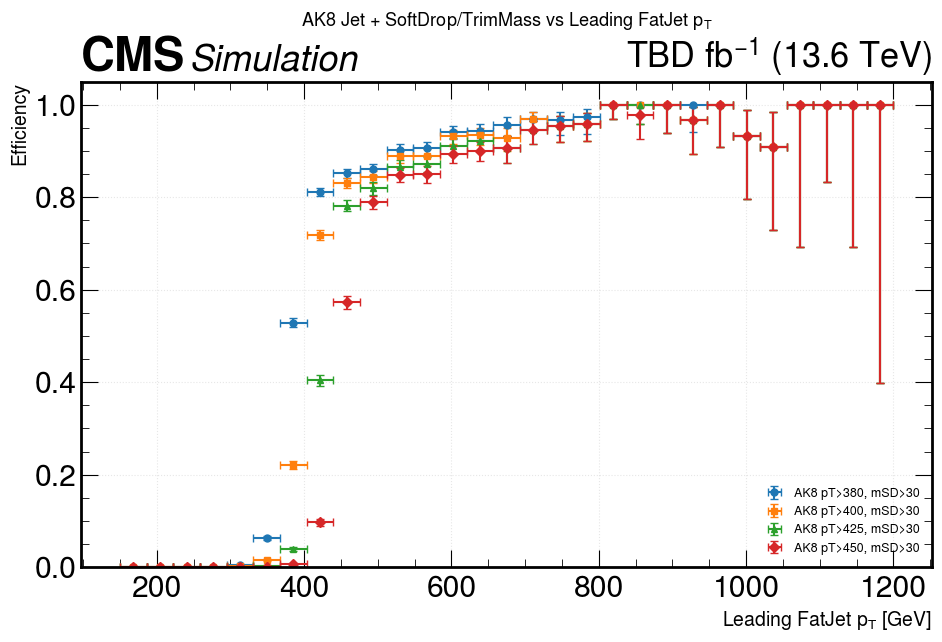

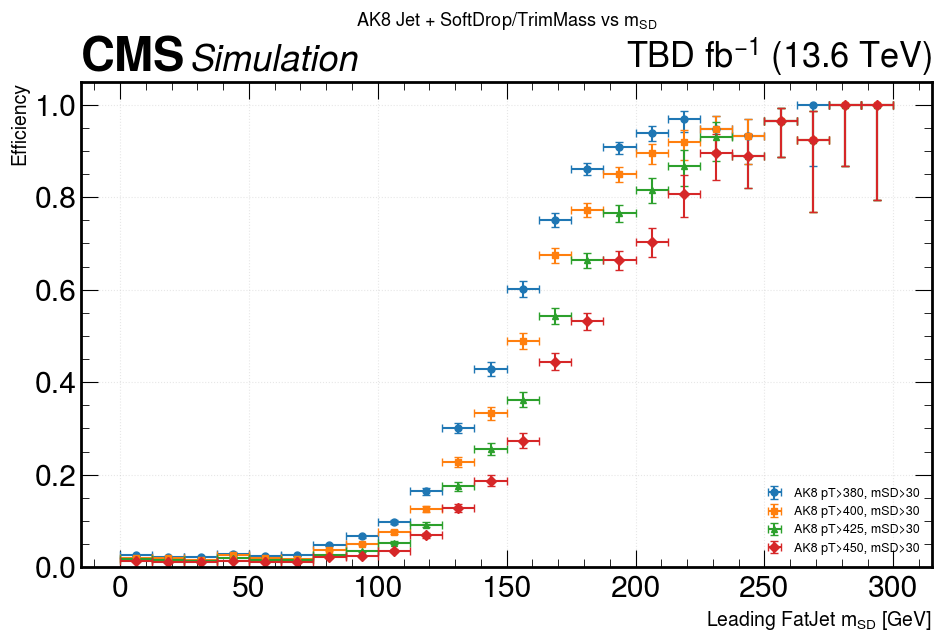

In [13]:
plot_eff(boosted_ak8jet_sd, "lead_fj_pt",
         r'Leading FatJet $p_T$ [GeV]',
         r'AK8 Jet + SoftDrop/TrimMass vs Leading FatJet $p_T$', lbl_ak8jet_sd)

plot_eff(boosted_ak8jet_sd, "lead_fj_msd",
         r'Leading FatJet $m_{SD}$ [GeV]',
         r'AK8 Jet + SoftDrop/TrimMass vs $m_{SD}$', lbl_ak8jet_sd)

## 12. AK8 DiPFJet + MassSD (NEW — boosted dijet topology)
New in Run 3, directly targeting boosted $t\bar{t}$ AK8 dijet events.
Require both leading and subleading AK8 jets above pT threshold + soft-drop mass cut.

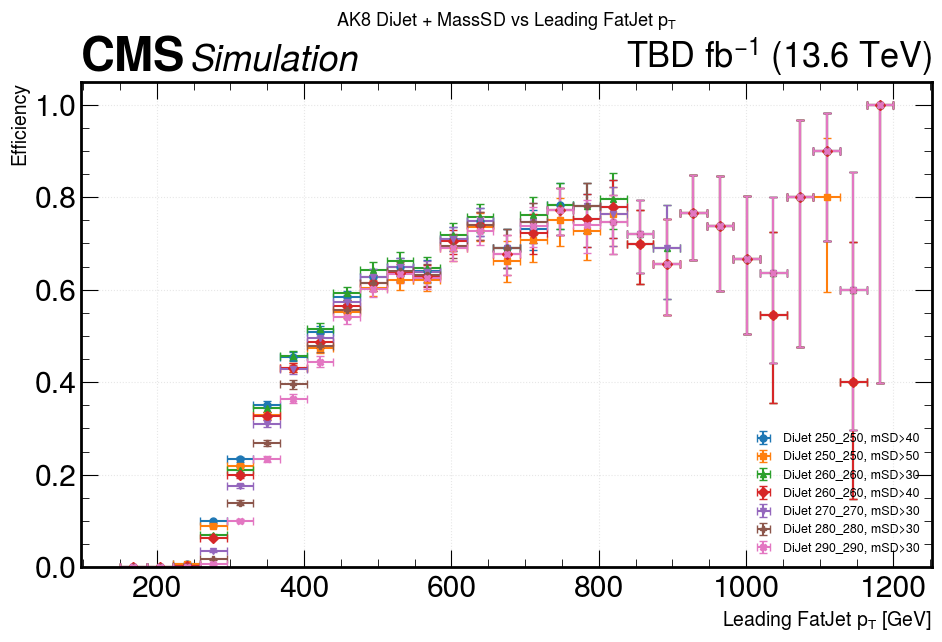

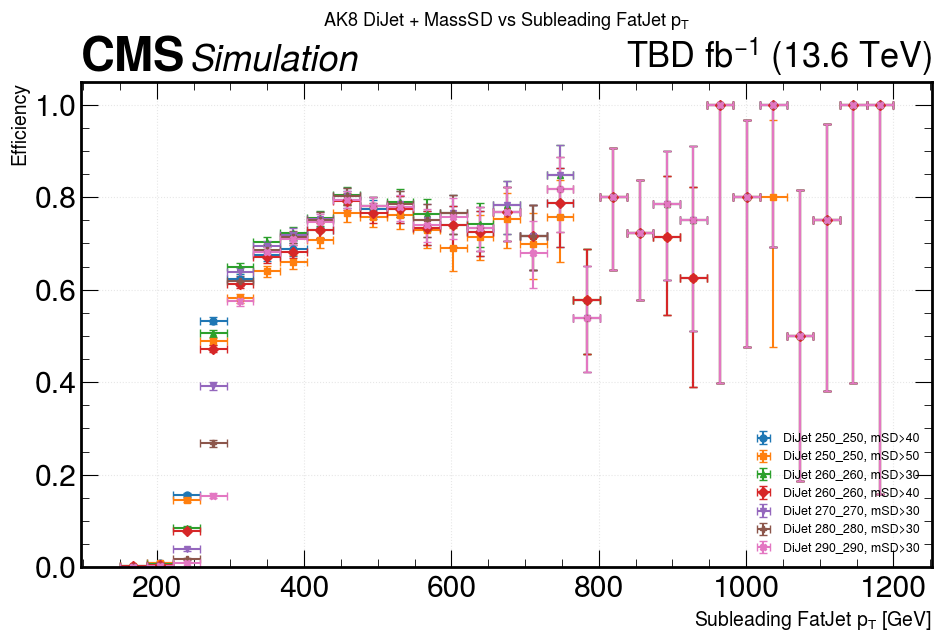

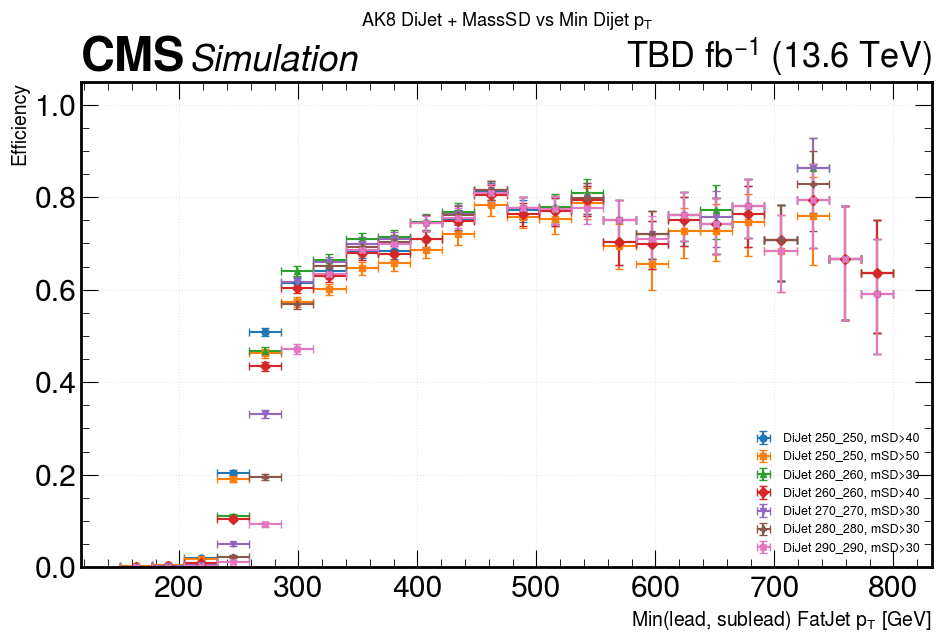

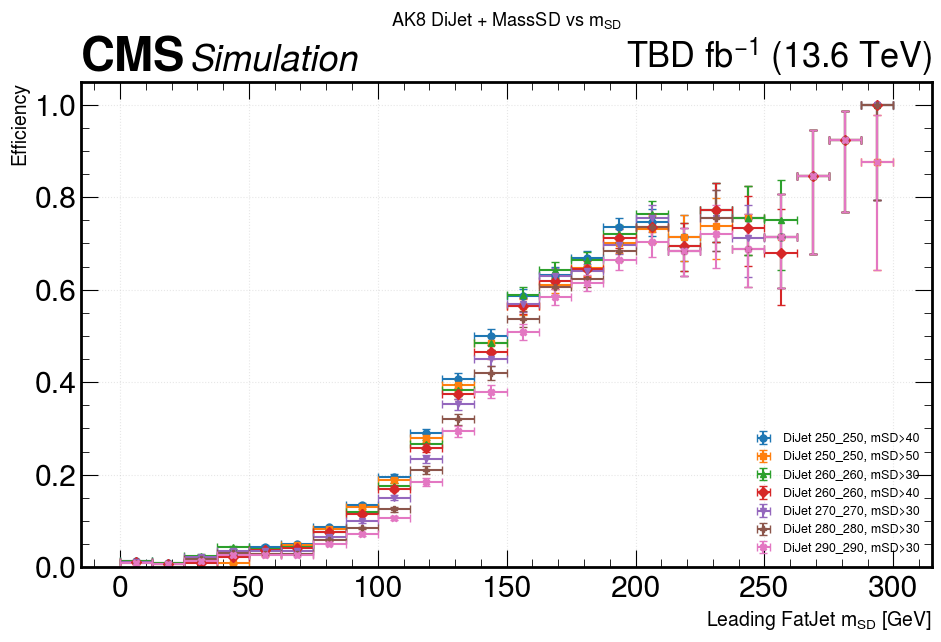

In [14]:
if boosted_ak8dijet:
    plot_eff(boosted_ak8dijet, "lead_fj_pt",
             r'Leading FatJet $p_T$ [GeV]',
             r'AK8 DiJet + MassSD vs Leading FatJet $p_T$', lbl_ak8dijet)

    plot_eff(boosted_ak8dijet, "sublead_fj_pt",
             r'Subleading FatJet $p_T$ [GeV]',
             r'AK8 DiJet + MassSD vs Subleading FatJet $p_T$', lbl_ak8dijet)

    plot_eff(boosted_ak8dijet, "dijet_min_pt",
             r'Min(lead, sublead) FatJet $p_T$ [GeV]',
             r'AK8 DiJet + MassSD vs Min Dijet $p_T$', lbl_ak8dijet)

    plot_eff(boosted_ak8dijet, "lead_fj_msd",
             r'Leading FatJet $m_{SD}$ [GeV]',
             r'AK8 DiJet + MassSD vs $m_{SD}$', lbl_ak8dijet)
else:
    print("No AK8 DiPFJet triggers found in this era.")

## 13. AK8 + MassSD (single jet, various thresholds)
Looser alternative to b-tagged paths — no tagger requirement, just pT + soft-drop mass.

In [15]:
if boosted_ak8jet_msd:
    plot_eff(boosted_ak8jet_msd, "lead_fj_pt",
             r'Leading FatJet $p_T$ [GeV]',
             r'AK8 Jet + MassSD vs Leading FatJet $p_T$', lbl_ak8jet_msd)

    plot_eff(boosted_ak8jet_msd, "lead_fj_msd",
             r'Leading FatJet $m_{SD}$ [GeV]',
             r'AK8 Jet + MassSD vs $m_{SD}$', lbl_ak8jet_msd)
else:
    print("No AK8 Jet + MassSD triggers found in this era.")

No AK8 Jet + MassSD triggers found in this era.


## 14. AK8 pure high-pT
No mass cut, just jet pT threshold.

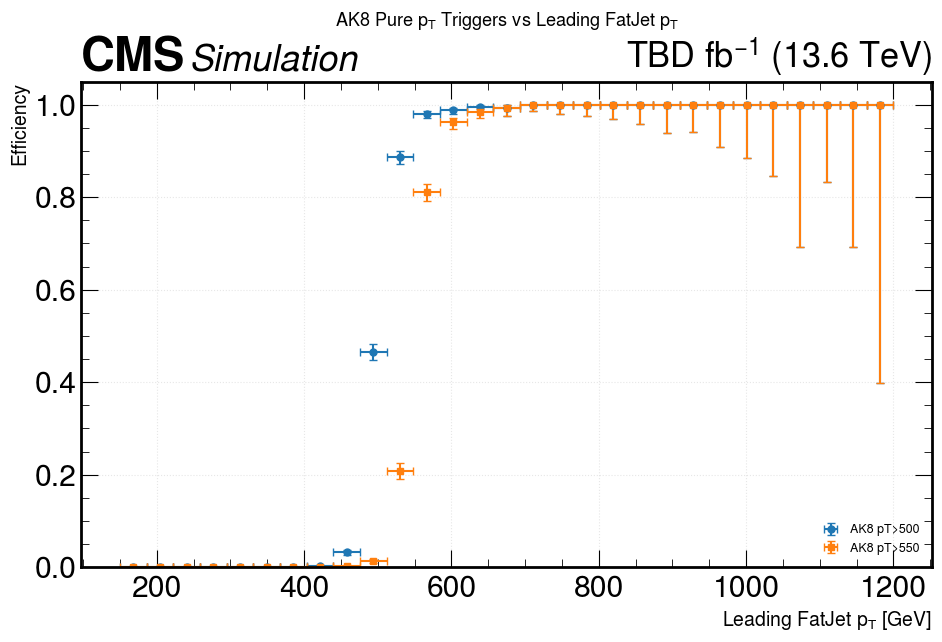

In [16]:
plot_eff(boosted_ak8jet_pt, "lead_fj_pt",
         r'Leading FatJet $p_T$ [GeV]',
         r'AK8 Pure $p_T$ Triggers vs Leading FatJet $p_T$', lbl_ak8jet_pt)

## 15. AK8 + ParticleNet / PNet b-tag (boosted)
Replaces Run 2's DeepCSV + BoostedDoubleB.  
2022 uses ParticleNetBB, 2023 uses PNetBB with lower thresholds.

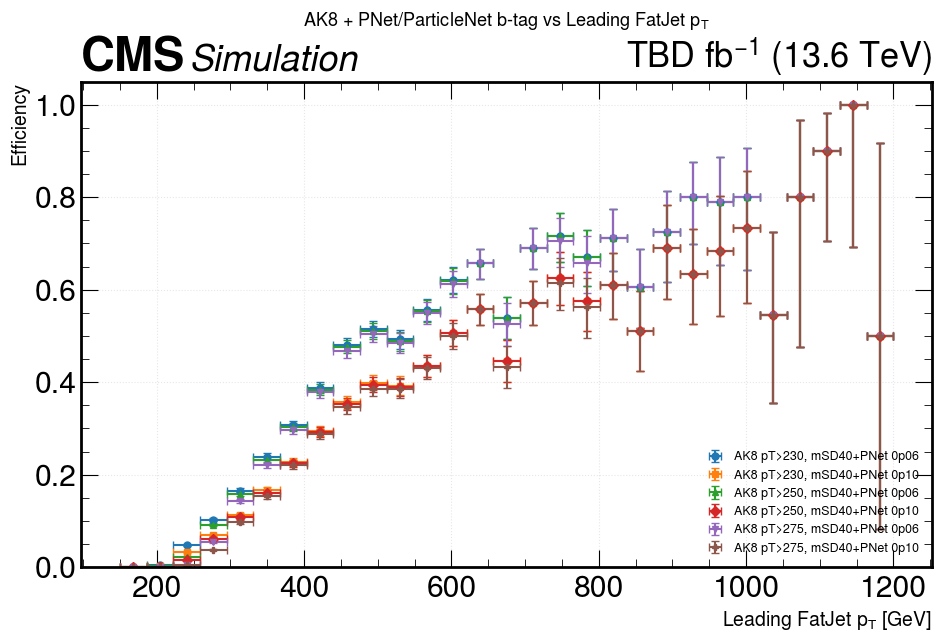

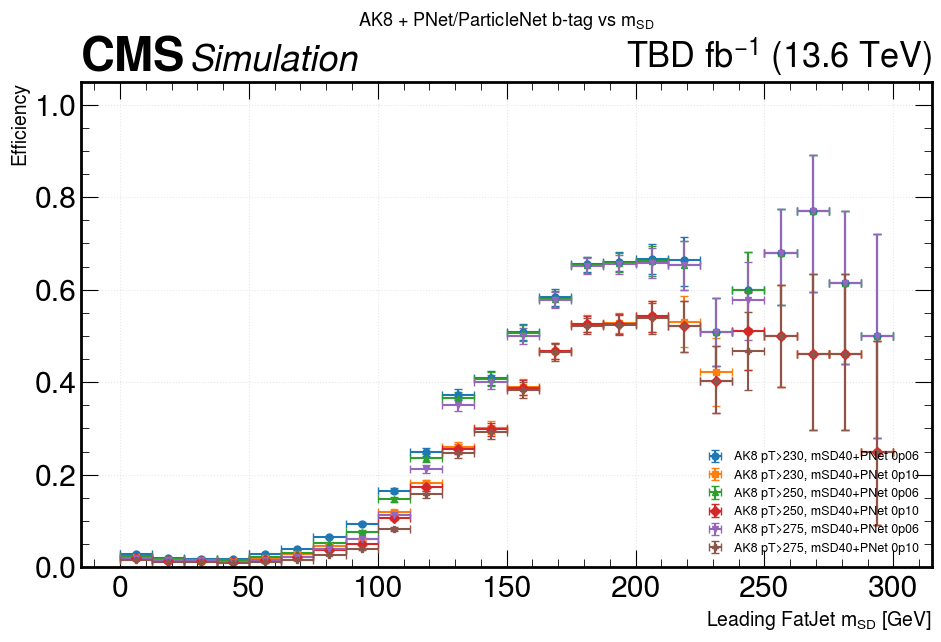

In [17]:
if boosted_ak8_pnet:
    plot_eff(boosted_ak8_pnet, "lead_fj_pt",
             r'Leading FatJet $p_T$ [GeV]',
             r'AK8 + PNet/ParticleNet b-tag vs Leading FatJet $p_T$', lbl_ak8_pnet)

    plot_eff(boosted_ak8_pnet, "lead_fj_msd",
             r'Leading FatJet $m_{SD}$ [GeV]',
             r'AK8 + PNet/ParticleNet b-tag vs $m_{SD}$', lbl_ak8_pnet)
else:
    print("No AK8 + PNet/ParticleNet triggers found in this era.")

## 16. Resolved multi-jet triggers (DeepJet / PNet)
Quad/Five/Six AK4 jet topologies with DeepJet (2022+2023) and PNet (2023) b-tagging.

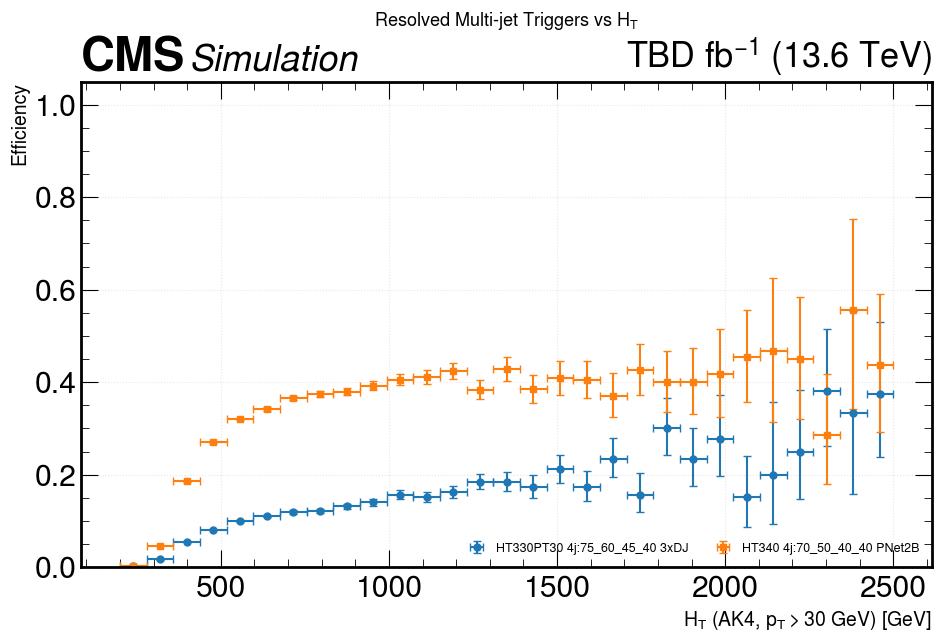

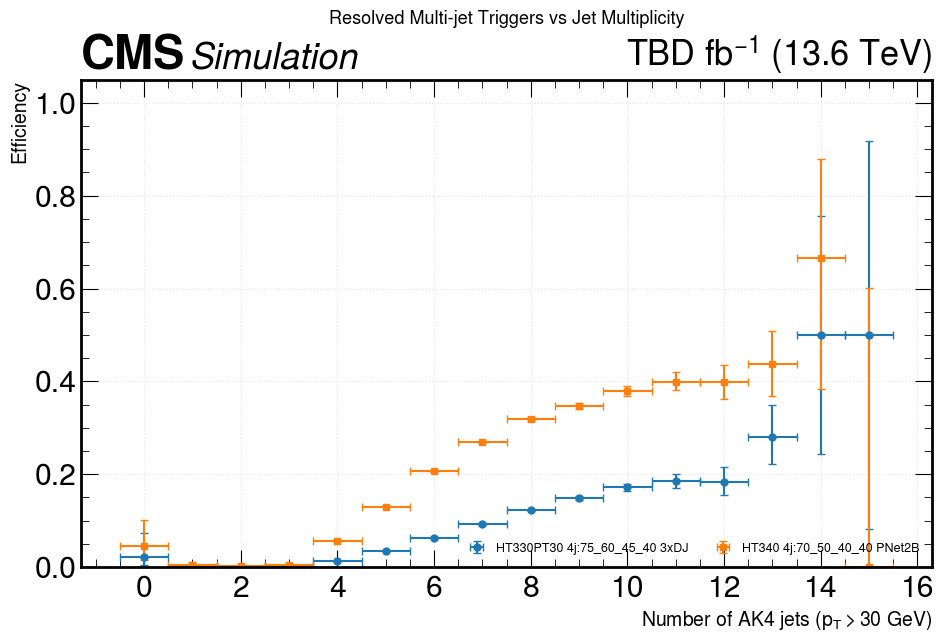

In [18]:
if resolved_multijet:
    plot_eff(resolved_multijet, "ht",
             r'$H_T$ (AK4, $p_T > 30$ GeV) [GeV]',
             r'Resolved Multi-jet Triggers vs $H_T$', lbl_resolved, ncol=2)

    plot_eff(resolved_multijet, "njet",
             r'Number of AK4 jets ($p_T > 30$ GeV)',
             r'Resolved Multi-jet Triggers vs Jet Multiplicity', lbl_resolved, ncol=2)
else:
    print("No resolved multi-jet triggers found.")

## 17. Inclusive PFHT
Pure HT threshold — reference trigger.

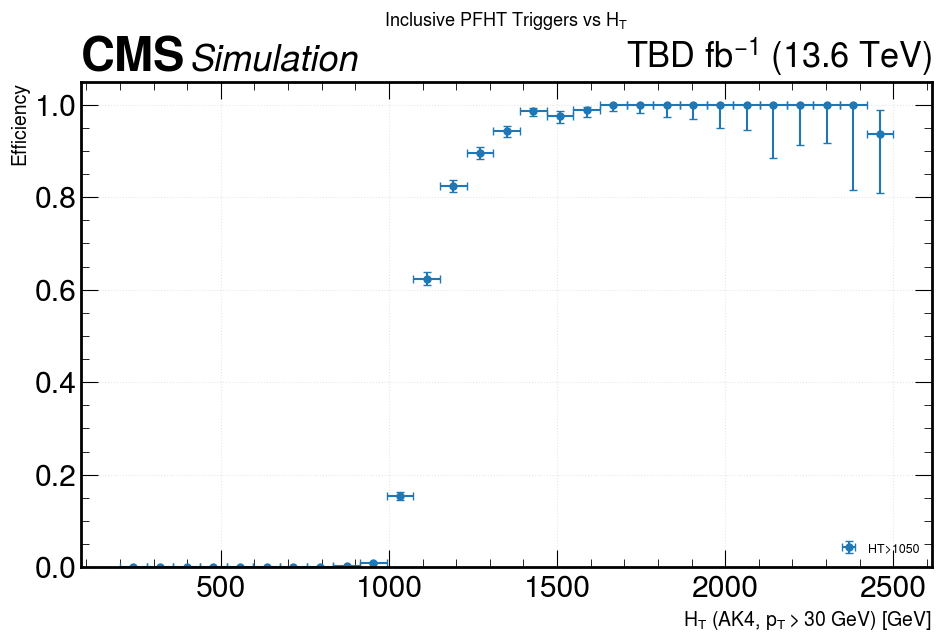

In [19]:
plot_eff(inclusive_pfht, "ht",
         r'$H_T$ (AK4, $p_T > 30$ GeV) [GeV]',
         r'Inclusive PFHT Triggers vs $H_T$', lbl_pfht)

## 16b. Hybrid AK8+AK4 PNet triggers (NEW in 2023)
Combines a boosted AK8 jet (pT > 220, mSD > 40, PNetBB) with resolved AK4 b-tagged jets.
These target events where one top is boosted and the other is resolved.

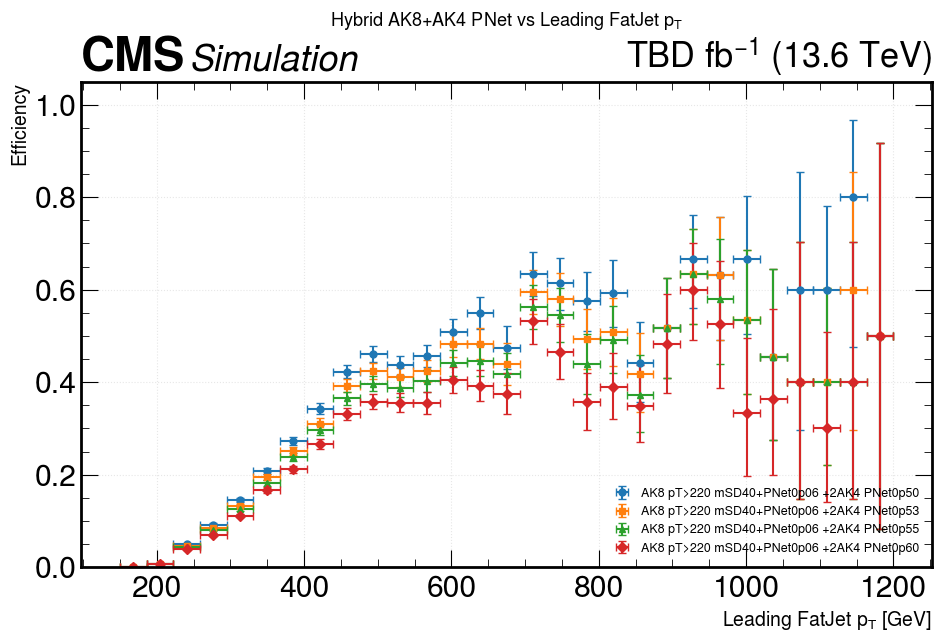

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


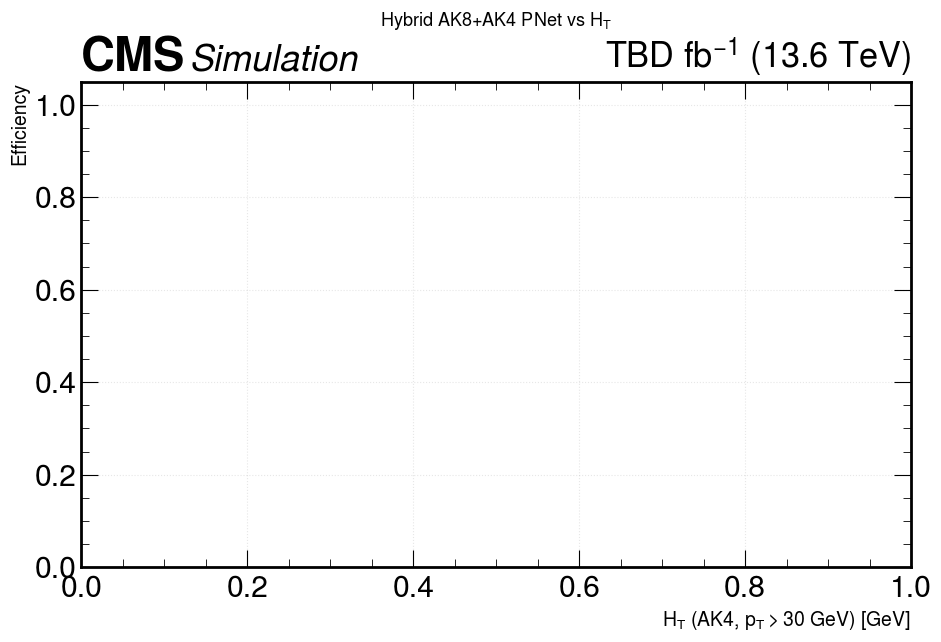

In [20]:
if hybrid_ak8_pnet:
    plot_eff(hybrid_ak8_pnet, "lead_fj_pt",
             r'Leading FatJet $p_T$ [GeV]',
             r'Hybrid AK8+AK4 PNet vs Leading FatJet $p_T$', lbl_hybrid, ncol=1)

    plot_eff(hybrid_ak8_pnet, "ht",
             r'$H_T$ (AK4, $p_T > 30$ GeV) [GeV]',
             r'Hybrid AK8+AK4 PNet vs $H_T$', lbl_hybrid, ncol=1)
else:
    print("No Hybrid AK8+AK4 PNet triggers found in this era.")

## 16c. AK8 Charged Multiplicity (Nch) triggers (NEW in 2024)
These triggers select AK8 jets with a minimum number of charged constituents.  
Targets quark-initiated jets (higher Nch) vs gluon jets (lower Nch).

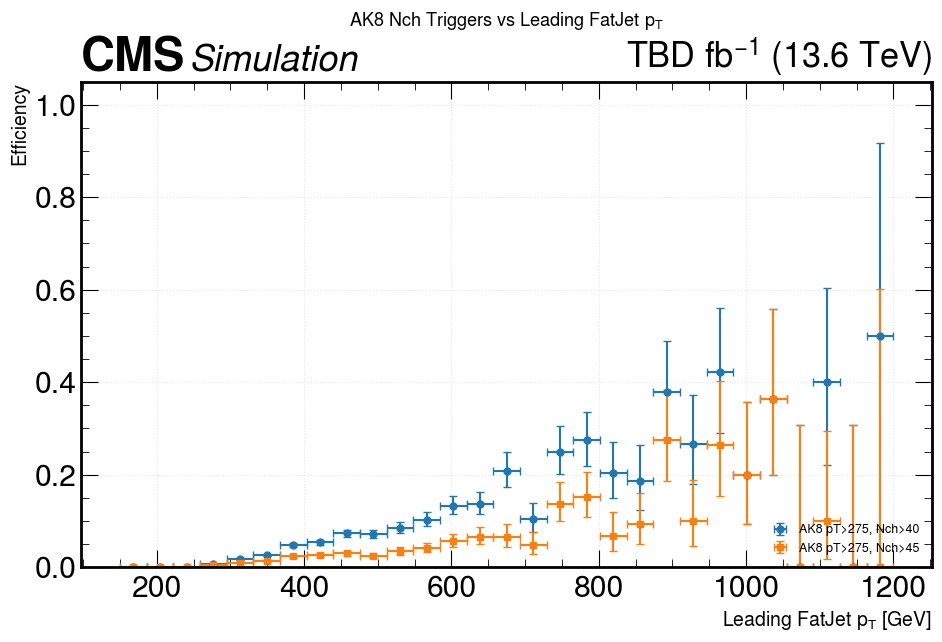

In [21]:
if boosted_ak8_nch:
    plot_eff(boosted_ak8_nch, "lead_fj_pt",
             r'Leading FatJet $p_T$ [GeV]',
             r'AK8 Nch Triggers vs Leading FatJet $p_T$', lbl_nch, ncol=1)
else:
    print("No AK8 Nch triggers found in this era.")

## 18. Best from each boosted group
One representative trigger per AK8 category, overlaid.

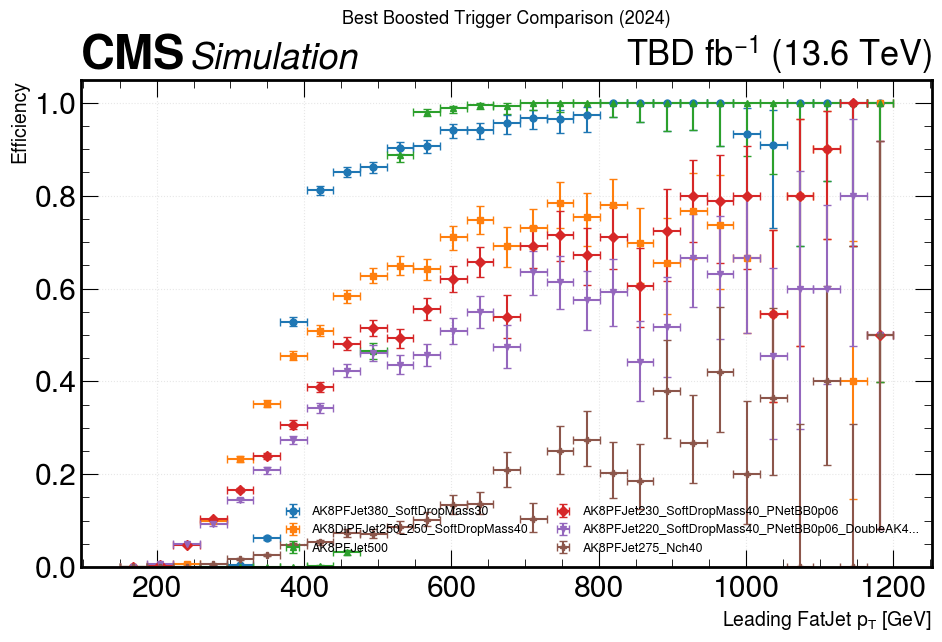

In [22]:
best = []
if boosted_ak8ht_trim:  best.append(boosted_ak8ht_trim[-1])
if boosted_ak8jet_sd:   best.append(boosted_ak8jet_sd[0])
if boosted_ak8dijet:    best.append(boosted_ak8dijet[0])
if boosted_ak8jet_msd:  best.append(boosted_ak8jet_msd[0])
if boosted_ak8jet_pt:   best.append(boosted_ak8jet_pt[0])
if boosted_ak8_pnet:    best.append(boosted_ak8_pnet[0])
if hybrid_ak8_pnet:     best.append(hybrid_ak8_pnet[0])
if boosted_ak8_nch:     best.append(boosted_ak8_nch[0])

plot_eff(best, "lead_fj_pt",
         r'Leading FatJet $p_T$ [GeV]',
         r'Best Boosted Trigger Comparison (2024)', lbl_short, ncol=2)

---
## 19. OR trigger efficiencies
Combined efficiency — this is what matters for the analysis.

In [23]:
def make_or(trig_list):
    mask = np.zeros(N, dtype=bool)
    for t in trig_list:
        mask |= ak.to_numpy(data[t]).astype(bool)
    return mask

# Boosted OR groups
m_bst_ht_trim  = make_or(boosted_ak8ht_trim)
m_bst_jet_sd   = make_or(boosted_ak8jet_sd)
m_bst_dijet    = make_or(boosted_ak8dijet)
m_bst_jet_msd  = make_or(boosted_ak8jet_msd)
m_bst_pt       = make_or(boosted_ak8jet_pt)
m_bst_pnet     = make_or(boosted_ak8_pnet)
m_hybrid       = make_or(hybrid_ak8_pnet)
m_nch          = make_or(boosted_ak8_nch)
m_all_bst      = m_bst_ht_trim | m_bst_jet_sd | m_bst_dijet | m_bst_jet_msd | m_bst_pt | m_bst_pnet | m_hybrid | m_nch

# Resolved OR
m_resolved = make_or(resolved_multijet)

# Inclusive
m_pfht = make_or(inclusive_pfht)

# Everything
m_everything = m_all_bst | m_resolved | m_pfht

# Denominators
denom_all = N
denom_1fj = int(np.sum(has_fj_np))
denom_2fj = int(np.sum(has_2fj_np))

print("OR TRIGGER EFFICIENCIES")
print("=" * 75)
print(f"  {'Label':<35} {'Passed':>8} {'Denom':>8} {'Eff':>7}  Denominator")
print(f"  {'-'*35} {'-'*8} {'-'*8} {'-'*7}  {'-'*15}")

or_table = [
    ("OR(AK8 HT+TrimMass)",       m_bst_ht_trim,  denom_1fj,  has_fj_np,  ">=1 FatJet"),
    ("OR(AK8 Jet+SoftDrop)",      m_bst_jet_sd,   denom_1fj,  has_fj_np,  ">=1 FatJet"),
    ("OR(AK8 DiJet+MassSD)",      m_bst_dijet,    denom_2fj,  has_2fj_np, ">=2 FatJets"),
    ("OR(AK8 Jet+MassSD)",        m_bst_jet_msd,  denom_1fj,  has_fj_np,  ">=1 FatJet"),
    ("OR(AK8 pure pT)",           m_bst_pt,       denom_1fj,  has_fj_np,  ">=1 FatJet"),
    ("OR(AK8 PNet b-tag)",        m_bst_pnet,     denom_1fj,  has_fj_np,  ">=1 FatJet"),
    ("OR(Hybrid AK8+AK4 PNet)",   m_hybrid,       denom_1fj,  has_fj_np,  ">=1 FatJet"),
    ("OR(AK8 Nch)",                m_nch,          denom_1fj,  has_fj_np,  ">=1 FatJet"),
    ("OR(ALL boosted AK8)",       m_all_bst,      denom_1fj,  has_fj_np,  ">=1 FatJet"),
    ("OR(Resolved multi-jet)",    m_resolved,     denom_all,  None,       "all events"),
    ("OR(PFHT)",                  m_pfht,         denom_all,  None,       "all events"),
    ("OR(EVERYTHING)",            m_everything,   denom_all,  None,       "all events"),
]

for label, mask, denom, denom_mask, denom_label in or_table:
    if denom_mask is not None:
        p = int(np.sum(mask[denom_mask]))
    else:
        p = int(np.sum(mask))
    eff = p / denom if denom > 0 else 0.0
    print(f"  {label:<35} {p:>8}/{denom:>7} = {100*eff:>5.1f}%  ({denom_label})")

OR TRIGGER EFFICIENCIES
  Label                                 Passed    Denom     Eff  Denominator
  ----------------------------------- -------- -------- -------  ---------------
  OR(AK8 HT+TrimMass)                        0/  84745 =   0.0%  (>=1 FatJet)
  OR(AK8 Jet+SoftDrop)                    7215/  84745 =   8.5%  (>=1 FatJet)
  OR(AK8 DiJet+MassSD)                    9254/  38829 =  23.8%  (>=2 FatJets)
  OR(AK8 Jet+MassSD)                         0/  84745 =   0.0%  (>=1 FatJet)
  OR(AK8 pure pT)                         2715/  84745 =   3.2%  (>=1 FatJet)
  OR(AK8 PNet b-tag)                      7751/  84745 =   9.1%  (>=1 FatJet)
  OR(Hybrid AK8+AK4 PNet)                 6992/  84745 =   8.3%  (>=1 FatJet)
  OR(AK8 Nch)                              978/  84745 =   1.2%  (>=1 FatJet)
  OR(ALL boosted AK8)                    14978/  84745 =  17.7%  (>=1 FatJet)
  OR(Resolved multi-jet)                 55970/ 314425 =  17.8%  (all events)
  OR(PFHT)                           

## 20. OR efficiency vs leading FatJet pT
The key plot — how much signal we keep as a function of fat jet pT.

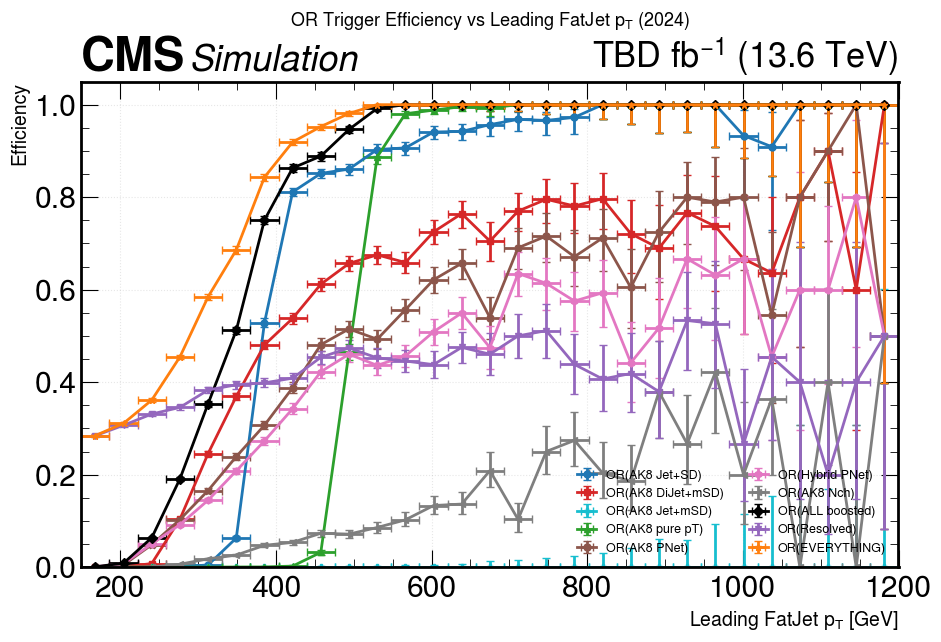

In [24]:
fig, ax = plt.subplots(figsize=(10, 7))

or_curves = [
    ("OR(AK8 Jet+SD)",     m_bst_jet_sd,   'tab:blue',   'o'),
    ("OR(AK8 DiJet+mSD)",  m_bst_dijet,    'tab:red',    's'),
    ("OR(AK8 Jet+mSD)",    m_bst_jet_msd,  'tab:cyan',   'P'),
    ("OR(AK8 pure pT)",    m_bst_pt,       'tab:green',  '^'),
    ("OR(AK8 PNet)",       m_bst_pnet,     'tab:brown',  'X'),
    ("OR(Hybrid PNet)",    m_hybrid,       'tab:pink',   'h'),
    ("OR(AK8 Nch)",        m_nch,          'tab:gray',   '<'),
    ("OR(ALL boosted)",    m_all_bst,      'black',      'D'),
    ("OR(Resolved)",       m_resolved,     'tab:purple', 'v'),
    ("OR(EVERYTHING)",     m_everything,   'tab:orange', '*'),
]

for label, mask, color, marker in or_curves:
    x, xw, eff, elo, ehi = calc_eff(mask[has_fj_np], lead_fj_pt, pt_bins)
    ax.errorbar(x, eff, xerr=xw, yerr=[elo, ehi],
                fmt=f'-{marker}', color=color, capsize=3, markersize=5,
                linewidth=2, label=label)

ax.set_ylim(0, 1.05)
ax.set_xlim(150, 1200)
ax.set_xlabel(r'Leading FatJet $p_T$ [GeV]', fontsize=14)
ax.set_ylabel('Efficiency', fontsize=14)
ax.legend(loc='lower right', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
hep.cms.text('Simulation', ax=ax)
hep.cms.lumitext(LUMI_TEXT, ax=ax)
ax.set_title(r'OR Trigger Efficiency vs Leading FatJet $p_T$ (2024)', fontsize=13, pad=40)
plt.tight_layout()
plt.show()

## 21. OR efficiency vs subleading FatJet pT
Critical for the boosted dijet topology — both jets need to be above threshold.

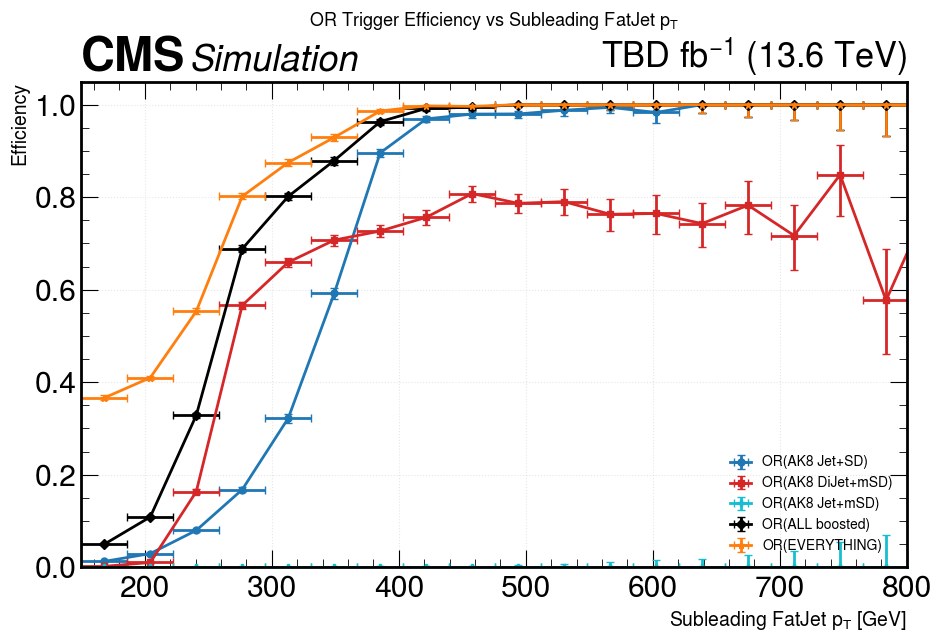

In [25]:
fig, ax = plt.subplots(figsize=(10, 7))

or_sub = [
    ("OR(AK8 Jet+SD)",     m_bst_jet_sd,   'tab:blue',   'o'),
    ("OR(AK8 DiJet+mSD)",  m_bst_dijet,    'tab:red',    's'),
    ("OR(AK8 Jet+mSD)",    m_bst_jet_msd,  'tab:cyan',   'P'),
    ("OR(ALL boosted)",    m_all_bst,      'black',      'D'),
    ("OR(EVERYTHING)",     m_everything,   'tab:orange', '*'),
]

for label, mask, color, marker in or_sub:
    x, xw, eff, elo, ehi = calc_eff(mask[has_2fj_np], sublead_fj_pt, pt_bins)
    ax.errorbar(x, eff, xerr=xw, yerr=[elo, ehi],
                fmt=f'-{marker}', color=color, capsize=3, markersize=5,
                linewidth=2, label=label)

ax.set_ylim(0, 1.05)
ax.set_xlim(150, 800)
ax.set_xlabel(r'Subleading FatJet $p_T$ [GeV]', fontsize=14)
ax.set_ylabel('Efficiency', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
hep.cms.text('Simulation', ax=ax)
hep.cms.lumitext(LUMI_TEXT, ax=ax)
ax.set_title(r'OR Trigger Efficiency vs Subleading FatJet $p_T$', fontsize=13, pad=40)
plt.tight_layout()
plt.show()

## 22. OR efficiency vs AK4 HT

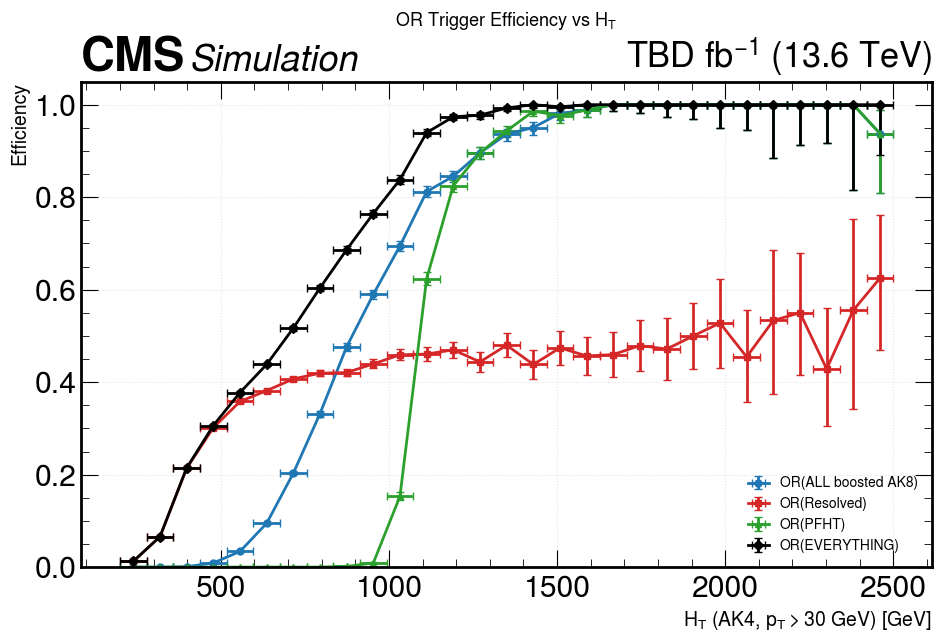

In [26]:
fig, ax = plt.subplots(figsize=(10, 7))

or_ht = [
    ("OR(ALL boosted AK8)", m_all_bst,   'tab:blue',  'o'),
    ("OR(Resolved)",        m_resolved,  'tab:red',   's'),
    ("OR(PFHT)",            m_pfht,      'tab:green', '^'),
    ("OR(EVERYTHING)",      m_everything,'black',     'D'),
]

for label, mask, color, marker in or_ht:
    x, xw, eff, elo, ehi = calc_eff(mask, ht, ht_bins)
    ax.errorbar(x, eff, xerr=xw, yerr=[elo, ehi],
                fmt=f'-{marker}', color=color, capsize=3, markersize=5,
                linewidth=2, label=label)

ax.set_ylim(0, 1.05)
ax.set_xlabel(r'$H_T$ (AK4, $p_T > 30$ GeV) [GeV]', fontsize=14)
ax.set_ylabel('Efficiency', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
hep.cms.text('Simulation', ax=ax)
hep.cms.lumitext(LUMI_TEXT, ax=ax)
ax.set_title(r'OR Trigger Efficiency vs $H_T$', fontsize=13, pad=40)
plt.tight_layout()
plt.show()

## 23. Full summary table

In [27]:
print(f"{'Trigger':<75} {'Passed':>8} {'Denom':>8} {'Eff':>7}  Denom")
print("=" * 115)
for group_name, group_list in all_groups:
    if not group_list:
        continue
    print(f"\n--- {group_name} ---")
    for trig in group_list:
        p, d, f, dlbl = overall[trig]
        print(f"  {trig:<73} {p:>8} {d:>8} {100*f:>6.1f}%  ({dlbl})")

Trigger                                                                       Passed    Denom     Eff  Denom

--- Boosted AK8 Jet+SoftDrop ---
  HLT_AK8PFJet380_SoftDropMass30                                                7215    84745    8.5%  (>=1 FJ)
  HLT_AK8PFJet400_SoftDropMass30                                                5951    84745    7.0%  (>=1 FJ)
  HLT_AK8PFJet425_SoftDropMass30                                                4714    84745    5.6%  (>=1 FJ)
  HLT_AK8PFJet450_SoftDropMass30                                                3721    84745    4.4%  (>=1 FJ)

--- Boosted AK8 DiJet+SoftDropMass ---
  HLT_AK8DiPFJet250_250_SoftDropMass40                                          8830    38829   22.7%  (>=2 FJ)
  HLT_AK8DiPFJet250_250_SoftDropMass50                                          8315    38829   21.4%  (>=2 FJ)
  HLT_AK8DiPFJet260_260_SoftDropMass30                                          8386    38829   21.6%  (>=2 FJ)
  HLT_AK8DiPFJet260_260_SoftDropM

In [28]:
_pdf_pages.close()
print(f"PDF saved: TEff_Run3_plots.pdf")

PDF saved: TEff_Run3_plots.pdf


## 24. DiJet trigger deep-dive (Run 3 exclusive)
Focused comparison of the new AK8DiPFJet triggers that directly target boosted ttbar.

##### if boosted_ak8dijet and boosted_ak8jet_sd:
    # Compare DiJet triggers against single-jet SD triggers
    compare = boosted_ak8dijet + boosted_ak8jet_sd[:2]  # DiJet + top 2 SoftDrop
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Left: vs lead FatJet pT
    ax = axes[0]
    for i, trig in enumerate(compare):
        if "lead_fj_pt" in eff_data.get(trig, {}):
            x, xw, eff, elo, ehi = eff_data[trig]["lead_fj_pt"]
            ax.errorbar(x, eff, xerr=xw, yerr=[elo, ehi],
                        fmt=MARKERS[i % len(MARKERS)], color=COLORS[i % len(COLORS)],
                        capsize=3, markersize=5, linewidth=1.5, label=lbl_short(trig))
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(r'Leading FatJet $p_T$ [GeV]', fontsize=14)
    ax.set_ylabel('Efficiency', fontsize=14)
    ax.legend(loc='lower right', fontsize=8, ncol=1)
    ax.grid(True, alpha=0.3)
    ax.set_title(r'DiJet vs Single-Jet: Leading $p_T$', fontsize=12)
    
    # Right: vs sublead FatJet pT (DiJet triggers only)
    ax = axes[1]
    for i, trig in enumerate(boosted_ak8dijet):
        if "sublead_fj_pt" in eff_data.get(trig, {}):
            x, xw, eff, elo, ehi = eff_data[trig]["sublead_fj_pt"]
            ax.errorbar(x, eff, xerr=xw, yerr=[elo, ehi],
                        fmt=MARKERS[i % len(MARKERS)], color=COLORS[i % len(COLORS)],
                        capsize=3, markersize=5, linewidth=1.5, label=lbl_ak8dijet(trig))
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(r'Subleading FatJet $p_T$ [GeV]', fontsize=14)
    ax.set_ylabel('Efficiency', fontsize=14)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title(r'DiJet Triggers: Subleading $p_T$', fontsize=12)
    
    hep.cms.text('Simulation', ax=axes[0])
    hep.cms.lumitext(LUMI_TEXT, ax=axes[1])
    plt.tight_layout()
    plt.show()
else:
    print("DiJet deep-dive skipped (no DiJet or SoftDrop triggers available).")